In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize
from scipy.special import expit
from scipy.stats import norm

In [3]:
data = pd.read_excel("/content/MultinomialData40.xlsx")

In [ ]:
data

,Y,X1
0,1,10
1,1,11
2,0,16
3,1,10
4,1,9
...,...,...
1495,0,10
1496,0,15
1497,1,14
1498,1,16


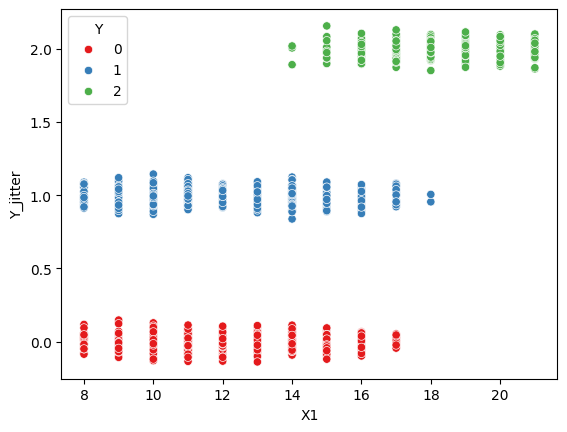

In [4]:
data["Y_jitter"] = data["Y"] + np.random.normal(0, 0.05, size=len(data))
sns.scatterplot(data=data, x="X1", y="Y_jitter", hue="Y", palette="Set1")
plt.show()

In [5]:
# Count number of occurrence of each Y.
# Y=0 administrative in A
# Y=1 administrative in B
# Y=2 management
data.groupby('Y').count()

,X1,Y_jitter
Y,,
0,486,486
1,476,476
2,538,538


## 1.e Ordered logit model

In [6]:
data_np = data.values
g_y = data_np[:, 0]
g_x1 = data_np[:, 1]

In [7]:
def MinusLogLOrderedLogit(par, g_y, g_x1):
    beta1 = par[0]
    tau1 = par[1]
    tau2 = par[2]

    if tau1 >= tau2:
        return 10 ** 10  # to prevent tau_1 >= tau_2

# Logistic CDF
    def G(z): return 1 / (1 + np.exp(-z))

    Pr_y_is_0_given_x = G(tau1 - beta1 * g_x1)
    Pr_y_is_1_given_x = G(tau2 - beta1 * g_x1) - G(tau1 - beta1 * g_x1)
    Pr_y_is_2_given_x = 1 - G(tau2 - beta1 * g_x1)

    Pr_y_given_x = (Pr_y_is_0_given_x ** (g_y == 0)) * \
                   (Pr_y_is_1_given_x ** (g_y == 1)) * \
                   (Pr_y_is_2_given_x ** (g_y == 2))

    loglikelihood = np.sum(np.log(Pr_y_given_x))
    return -loglikelihood

In [8]:
# Initial values for numerical optimization:
beta1_ini = 0.0
tau1_ini = -1.0
tau2_ini = 1.0
par_ini = [beta1_ini, tau1_ini, tau2_ini]
EstimationResult = minimize(MinusLogLOrderedLogit, par_ini, args=(g_y, g_x1), method="BFGS")
par_MLE = EstimationResult.x
loglik_1e = -EstimationResult.fun

In [9]:
par_MLE

array([0.51975096, 6.02453005, 8.33872897])

In [10]:
loglik_1e

np.float64(-1151.757297586716)

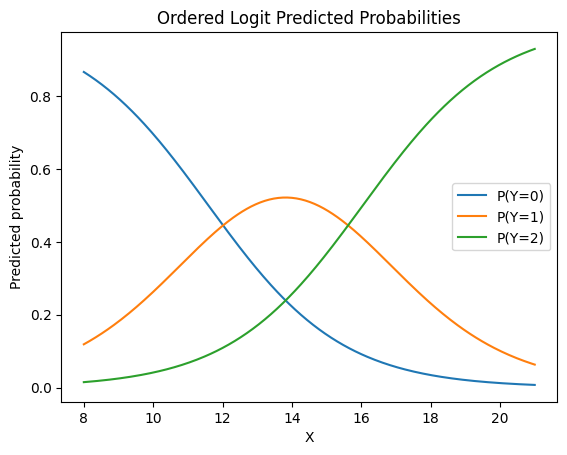

In [11]:
# Estimated parameters
beta = par_MLE[0]
tau1 = par_MLE[1]
tau2 = par_MLE[2]

# Grid of X values
x_grid = np.linspace(data["X1"].min(), data["X1"].max(), 300)

# Predicted probabilities
P0 = expit(tau1 - beta * x_grid)
P1 = expit(tau2 - beta * x_grid) - expit(tau1 - beta * x_grid)
P2 = 1 - expit(tau2 - beta * x_grid)

# Plot
plt.plot(x_grid, P0, label="P(Y=0)")
plt.plot(x_grid, P1, label="P(Y=1)")
plt.plot(x_grid, P2, label="P(Y=2)")

plt.xlabel("X")
plt.ylabel("Predicted probability")
plt.legend()
plt.title("Ordered Logit Predicted Probabilities")
plt.show()

## 1.f Ordered logit model (opposite)

In [12]:
# Change the ordering of the data 2->0, 1->1, 0->2
g_y_tilde = 2 - g_y

In [13]:
g_y_tilde

array([1., 1., 2., ..., 1., 1., 0.])

In [14]:
# Estimate opposite logit model
EstimationResult1f = minimize(MinusLogLOrderedLogit, par_ini, args=(g_y_tilde, g_x1), method="BFGS")
par_MLE_1f = EstimationResult1f.x
par_MLE_1f

array([-0.5197511 , -8.33873093, -6.02453161])

In [15]:
# Log Likelihood, should match 1e
loglik_1f = -EstimationResult1f.fun
loglik_1f

np.float64(-1151.7572975867117)

## 1.g Multinomial logit model


In [16]:
def MinusLogLMultinomialLogit(par, g_y, g_x1):
    beta0_1 = par[0]
    beta1_1 = par[1]
    beta0_2 = par[2]
    beta1_2 = par[3]
    exp_xbeta1 = np.exp(beta0_1 + beta1_1 * g_x1)
    exp_xbeta2 = np.exp(beta0_2 + beta1_2 * g_x1)
    Pr_y_is_0_given_x = 1 / (1 + exp_xbeta1 + exp_xbeta2)
    Pr_y_is_1_given_x = exp_xbeta1 / (1 + exp_xbeta1 + exp_xbeta2)
    Pr_y_is_2_given_x = exp_xbeta2 / (1 + exp_xbeta1 + exp_xbeta2)
    Pr_y_given_x = (Pr_y_is_0_given_x ** (g_y == 0)) * \
                   (Pr_y_is_1_given_x ** (g_y == 1)) * \
                   (Pr_y_is_2_given_x ** (g_y == 2))
    loglikelihood = np.sum(np.log(Pr_y_given_x))
    return -loglikelihood

In [17]:
    # Initial values for numerical optimization:
    par_ini_mnl = np.zeros(4)

    # Estimation: MINimize function MinusLogLMultinomialLogit:
    EstimationResult1g = minimize(MinusLogLMultinomialLogit, par_ini_mnl, args=(g_y, g_x1), method="BFGS")
    par_MLE_1g = EstimationResult1g.x
    loglik_1g = -EstimationResult1g.fun

In [18]:
par_MLE_1g

array([-7.10961768e-02,  4.14823268e-03, -2.83842413e+01,  1.79858069e+00])

In [19]:
loglik_1g

np.float64(-867.7096740055633)

In [20]:
def plot_multinomial_logit_model(par_MLE_1g):
    # Estimated parameters
    beta0_1, beta1_1, beta0_2, beta1_2 = par_MLE_1g
    # Grid of X values
    x_grid = np.linspace(g_x1.min(), g_x1.max(), 400)
    # Linear indices
    xb1 = beta0_1 + beta1_1 * x_grid
    xb2 = beta0_2 + beta1_2 * x_grid
    # Exponentials
    exp_xb1 = np.exp(xb1)
    exp_xb2 = np.exp(xb2)
    # Probabilities
    denom = 1 + exp_xb1 + exp_xb2
    P0 = 1 / denom
    P1 = exp_xb1 / denom
    P2 = exp_xb2 / denom
    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(x_grid, P0, label="P(Y=0)")
    plt.plot(x_grid, P1, label="P(Y=1)")
    plt.plot(x_grid, P2, label="P(Y=2)")
    plt.xlabel("X")
    plt.ylabel("Predicted probability")
    plt.title("Estimated Multinomial Logit Probabilities")
    plt.legend()
    plt.ylim(0, 1)
    plt.show()

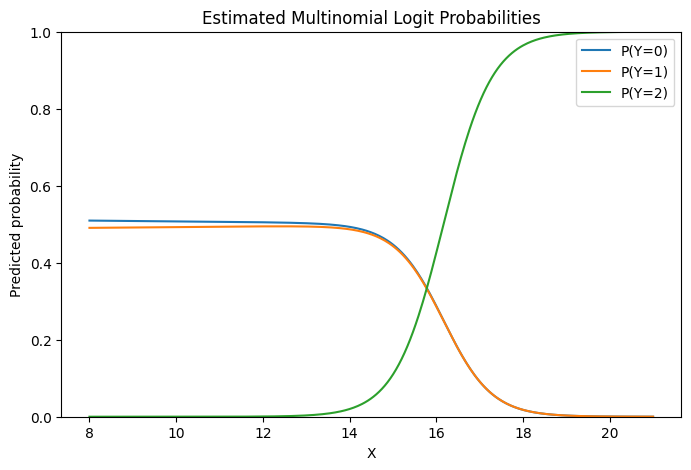

In [21]:
plot_multinomial_logit_model(par_MLE_1g)

## 1.h Model selection based on AIC

In [22]:
# Alternative dependent variables
y_prime = np.zeros_like(g_y)
y_prime[g_y == 0] = 0
y_prime[g_y == 2] = 1
y_prime[g_y == 1] = 2

y_double_prime = np.zeros_like(g_y)
y_double_prime[g_y == 1] = 0
y_double_prime[g_y == 0] = 1
y_double_prime[g_y == 2] = 2

# Model 1 - ordered logit (y)
EstimationResult = minimize(MinusLogLOrderedLogit, par_ini, args=(g_y, g_x1), method="BFGS")
loglik1 = -EstimationResult.fun
aic_ord_y = 2 * 3 + 2 * loglik1

# Model 2 - ordered logit (y')
EstimationResult_prime = minimize(MinusLogLOrderedLogit, par_ini, args=(y_prime, g_x1), method="BFGS")
loglik2 = -EstimationResult_prime.fun
aic_ord_y_prime = 2 * 3 + 2 * loglik2

# Model 3 - ordered logit (y'')
EstimationResult_double_prime = minimize(MinusLogLOrderedLogit, par_ini, args=(y_double_prime, g_x1), method="BFGS")
loglik3 = -EstimationResult_double_prime.fun
aic_ord_y_double_prime = 2 * 3 + 2 * loglik3

# Model 4 - multinomial logit (y)
EstimationResult_mnl = minimize(MinusLogLMultinomialLogit, par_ini_mnl, args=(g_y, g_x1), method="BFGS")
loglik4 = -EstimationResult_mnl.fun
aic_mnl_y = 2 * 4 + 2 * loglik4

# Print results
print(f"AIC Ordered Logit (y) : {aic_ord_y:.2f}")
print(f"AIC Ordered Logit (y') : {aic_ord_y_prime:.2f}")
print(f"AIC Ordered Logit (y'') : {aic_ord_y_double_prime:.2f}")
print(f"AIC Multinomial Logit (y) : {aic_mnl_y:.2f}")

AIC Ordered Logit (y) : -2297.51
AIC Ordered Logit (y') : -3285.30
AIC Ordered Logit (y'') : -2303.96
AIC Multinomial Logit (y) : -1727.42


## 1.i Multinomial logit model for y''

In [24]:
# Estimate model
EstimationResult_mnl_double_prime = minimize(MinusLogLMultinomialLogit, par_ini_mnl, args=(y_double_prime, g_x1), method="BFGS")

# Extract coefficients (for y'')
beta0_1_double_prime = EstimationResult_mnl_double_prime.x[0]
beta1_1_double_prime = EstimationResult_mnl_double_prime.x[1]
beta0_2_double_prime = EstimationResult_mnl_double_prime.x[2]
beta1_2_double_prime = EstimationResult_mnl_double_prime.x[3]

# Extract coefficients for y
beta0_1 = EstimationResult_mnl.x[0]
beta1_1 = EstimationResult_mnl.x[1]
beta0_2 = EstimationResult_mnl.x[2]
beta1_2 = EstimationResult_mnl.x[3]

# Compare log likelihood of both models
print(f"Log-Likelihood (y): {-EstimationResult_mnl.fun:.4f}")
print(f"Log-Likelihood (y''): {-EstimationResult_mnl_double_prime.fun:.4f}\n")


# Calculate theoretical coefficients
theoretical_beta0_1 = -beta0_1
theoretical_beta1_1 = -beta1_1
theoretical_beta0_2 = beta0_2 - beta0_1
theoretical_beta1_2 = beta1_2 - beta1_1

# Compare coefficients for y'' = 1 (which is y = 0)
print(f"Beta0^(1)_tilde: {beta0_1_double_prime:.4f}  | Theoretical: {theoretical_beta0_1:.4f}")
print(f"Beta1^(1)_tilde: {beta1_1_double_prime:.4f}  | Theoretical: {theoretical_beta1_1:.4f}\n")

# Compare coefficients for y'' = 2 (which is y = 2)
print(f"Beta0^(2)_tilde: {beta0_2_double_prime:.4f}  | Theoretical: {theoretical_beta0_2:.4f}")
print(f"Beta1^(2)_tilde: {beta1_2_double_prime:.4f}  | Theoretical: {theoretical_beta1_2:.4f}")

Log-Likelihood (y): -867.7097
Log-Likelihood (y''): -867.7097

Beta0^(1)_tilde: 0.0711  | Theoretical: 0.0711
Beta1^(1)_tilde: -0.0041  | Theoretical: -0.0041

Beta0^(2)_tilde: -28.3132  | Theoretical: -28.3131
Beta1^(2)_tilde: 1.7944  | Theoretical: 1.7944
